数据处理部分（Extract, Transform, Load）使用 Spark DataFrame API 实现，生存分析模型部分（lifelines 库）则保留在 Pandas 层面进行计算。

1.环境初始化与 Spark 会话创建

在此部分，我们将启动 Spark 会话并安装必要的第三方库，确保环境能够处理生存分析所需的复杂计算。

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter, LogLogisticAFTFitter
from lifelines.statistics import pairwise_logrank_test
import warnings

# 1.1 初始化 Spark Session (配置为本地模式)
spark = SparkSession.builder \
    .appName("Telco_Customer_Survival_Analysis") \
    .getOrCreate()

# 1.2 安装生存分析及绘图所需的依赖库
!pip install --quiet "grpcio-status>=1.76.0" "zstandard>=0.25.0" --no-deps
!pip install lifelines matplotlib seaborn pandas numpy ipywidgets --quiet

# 1.3 绘图全局配置
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

print("✅ Spark 环境与依赖库配置完成！")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/25 16:35:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark 环境与依赖库配置完成！


2. 数据加载与清洗（Silver 层）

直接从 GitHub 加载 IBM Telco Customer Churn 数据集，并清洗为分析用 silver 数据。

In [8]:
# 直接从官方链接加载原始数据
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
telco = pd.read_csv(url)
telco_pp = pd.read_csv(url)

# 数据清洗（生成 silver 层）
silver_df = (telco
             .assign(churn = lambda x: (x['Churn'] == 'Yes').astype(int))
             .query("Contract == 'Month-to-month' and InternetService != 'No'").drop(columns=['Churn']))

telco_pd = silver_df.copy() 
print(f"原始数据形状: {telco.shape}")
print(f"清洗后 silver 数据形状: {telco_pd.shape}")
telco_pd.head()

原始数据形状: (7043, 21)
清洗后 silver 数据形状: (3351, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,0


在Python中清洗数据并导出CSV用于后续数据库处理

In [10]:
# 处理 TotalCharges 中的空格（核心步骤）
# 将空格替换为 0，确保数据库导入时不会因为类型不匹配报错
telco_pp['TotalCharges'] = telco_pp['TotalCharges'].replace(' ', '0')
telco_pp['TotalCharges'] = pd.to_numeric(telco_pp['TotalCharges'])

# 3. 将 Churn 转换为数字 1/0（方便后续生存分析 SQL 查询）
telco_pp['Churn'] = telco_pp['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 4. 导出为 CSV 文件到服务器本地，不保存索引
# 注意：使用逗号分隔，并确保没有索引列
telco_pp.to_csv('cleaned_telco.csv', index=False)
print("清洗后的数据已保存至：cleaned_telco.csv")

清洗后的数据已保存至：cleaned_telco.csv


3. Kaplan-Meier 生存分析

KM 曲线用于描述在不考虑协变量的情况下，客户随时间推移（Tenure）保持留存的概率。

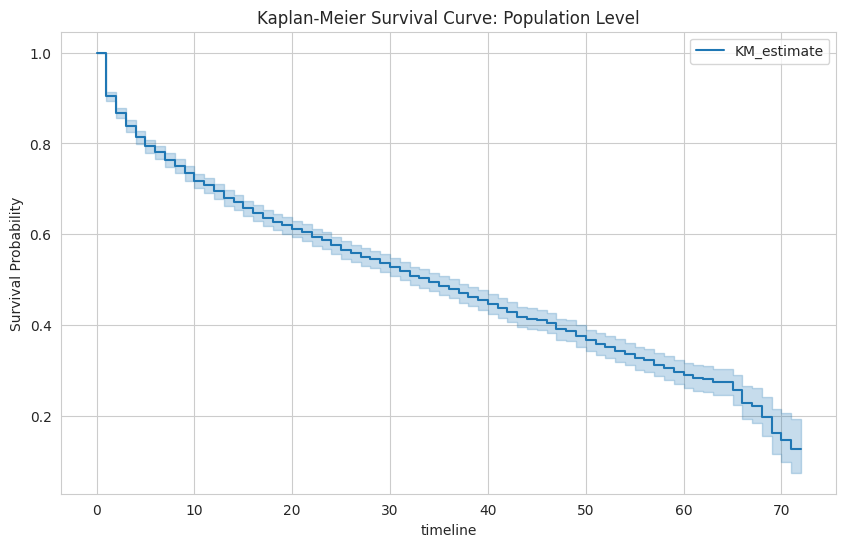

客户留存中位数时间 (Median survival time): 34.0 个月


In [11]:
# 3.1 初始化 Kaplan-Meier 拟合器
kmf = KaplanMeierFitter()
T = telco_pd['tenure']
C = telco_pd['churn'].astype(float)

# 3.2 拟合数据并绘制全量人群生存曲线
kmf.fit(T, C)
kmf.plot(title='Kaplan-Meier Survival Curve: Population Level')
plt.ylabel('Survival Probability')
plt.show()

print(f"客户留存中位数时间 (Median survival time): {kmf.median_survival_time_} 个月")

4. 维度细分下的生存差异分析 (Log-rank Test)

通过定义辅助函数，我们能够快速对比不同服务维度（如 OnlineSecurity）对流失风险的影响。

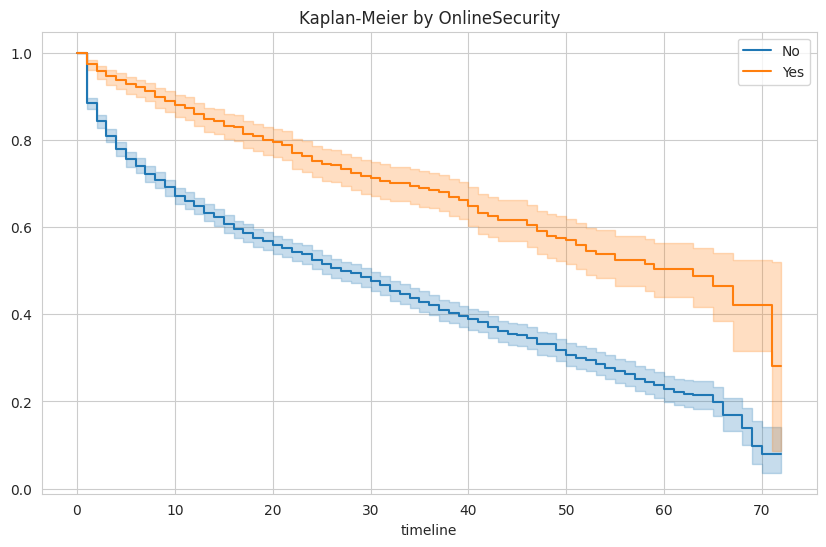

--- Log-rank Test for OnlineSecurity ---
        test_statistic             p    -log2(p)
No Yes       141.60316  1.187554e-32  106.053706

DSL 客户前 10 个月的生存概率预测:


,DSL
0,1.000000
1,0.902698
2,0.864380
3,0.834702
4,0.810522
5,0.794352
6,0.783900
7,0.776362
8,0.768486
9,0.750833


In [12]:
# 4.1 定义绘图函数：按列的不同取值绘制多条 KM 曲线
def plot_km(col):
    ax = plt.subplot(111)
    for r in telco_pd[col].unique():
        ix = telco_pd[col] == r
        kmf.fit(T[ix], C[ix], label=r)
        kmf.plot(ax=ax)
    plt.title(f'Kaplan-Meier by {col}')
    plt.show()

# 4.2 定义统计检验函数：使用 Log-rank 测试判断组间生存差异是否显著
def print_logrank(col):
    log_rank = pairwise_logrank_test(telco_pd['tenure'], telco_pd[col], telco_pd['churn'])
    print(f"--- Log-rank Test for {col} ---")
    print(log_rank.summary)

# 4.3 示例：分析网络安全服务对流失的影响
plot_km('OnlineSecurity')
print_logrank('OnlineSecurity')

# 4.4 提取特定子集的生存概率矩阵 (以 DSL 客户为例)
def get_survival_probs(col, val):
    ix = telco_pd[col] == val
    return kmf.fit(T[ix], C[ix], label=val)

sp_internet_dsl = get_survival_probs('InternetService', 'DSL')
print("\nDSL 客户前 10 个月的生存概率预测:")
display(pd.DataFrame(sp_internet_dsl.survival_function_at_times(range(0, 10))))

5. Cox 比例风险回归模型

Cox 模型用于分析多个因素（协变量）如何共同影响客户流失风险。

<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 3351
number of events observed = 1556
   partial log-likelihood = -11315.95
         time fit was run = 2026-04-25 08:39:54 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Dependents_Yes      -0.33      0.72      0.07           -0.47           -0.19                0.63                0.83
InternetService_DSL -0.22      0.80      0.06           -0.33           -0.10                0.72                0.90
OnlineBackup_Yes    -0.78      0.46      0.06           -0.89           -0.66                0.41                0.52
TechSupport_Yes     -0.64      0.53      0.08           -0.79           -0.49                0.46                0.61

                     cmp to      z      p  -log2(p)
covariate                                          
Dependents_Yes         0.00  -4.64 <0.005     18.12
InternetService_DSL    0.00  -3.68 <0.005     12.07
OnlineBackup_Yes       0.00 -13.13 <0.005    128.37
TechSupport_Yes        0.00  -8.48 <0.005     55.36
---
Concordance = 0.64
Partial AIC = 22639.90
log-likelihood ratio test = 337.77 on 4 df
-log2(p) of ll-ratio test = 236.24

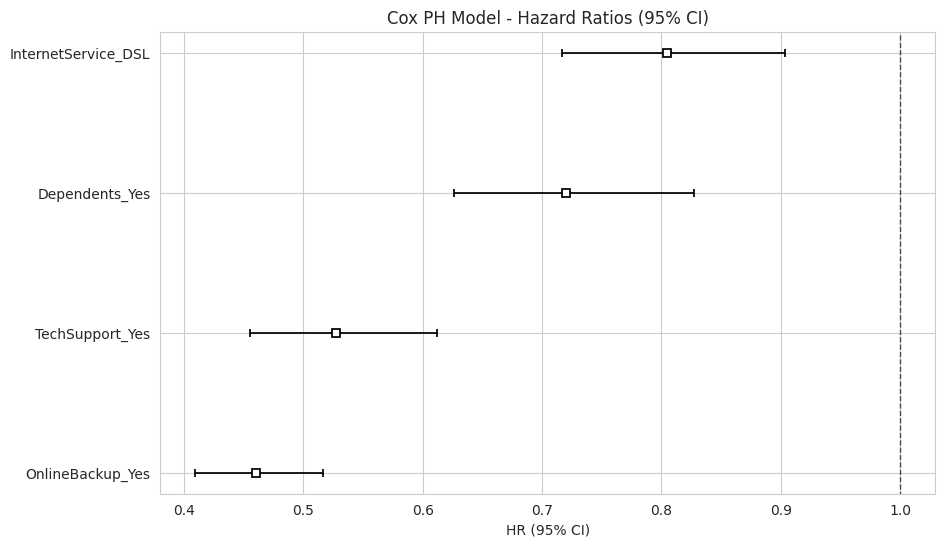

正在执行比例风险假设检验...

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'InternetService_DSL' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['InternetService_DSL', ...]`
in the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'OnlineBackup_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


3. Variable 'TechSupport_Yes' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['TechSupport_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/lat

[[<Axes: xlabel='rank-transformed time\n(p=0.3680)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2232)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0002)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0044)'>]]

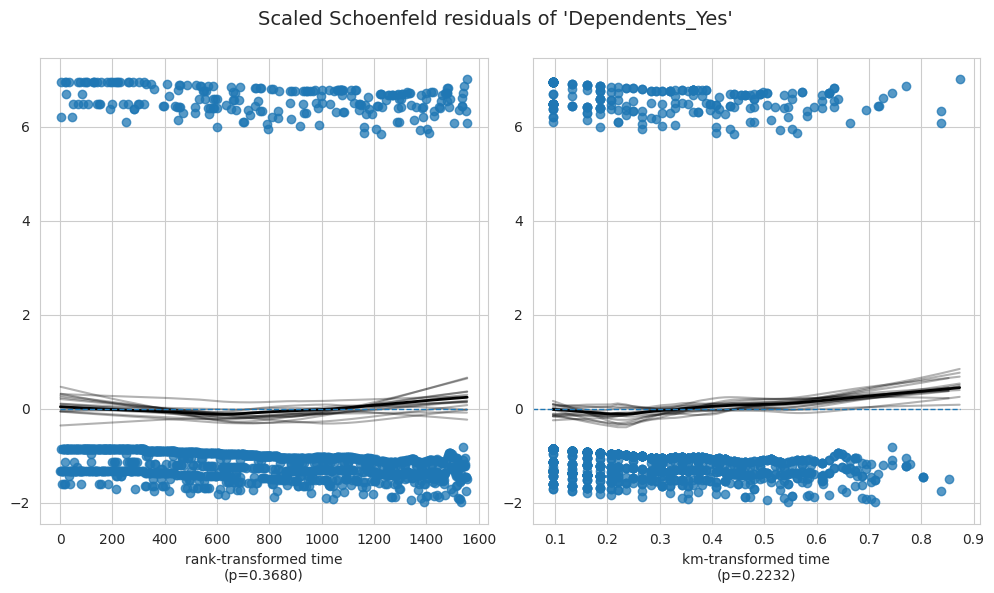

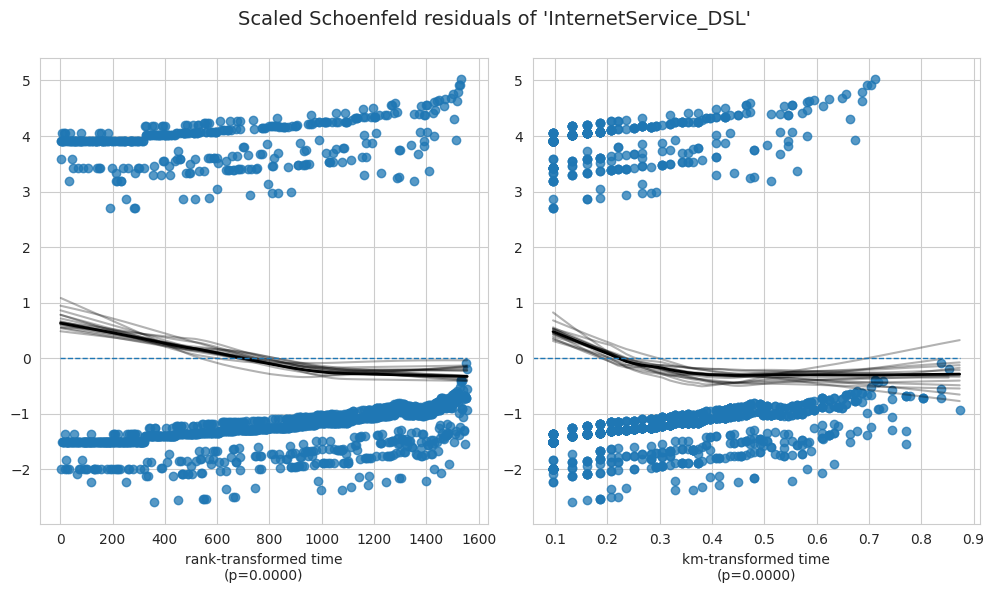

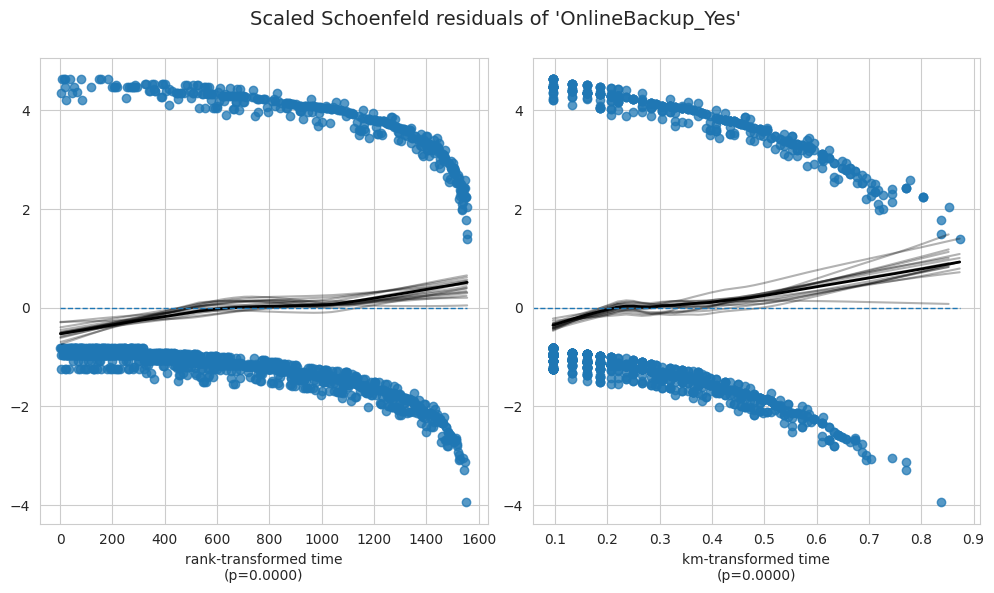

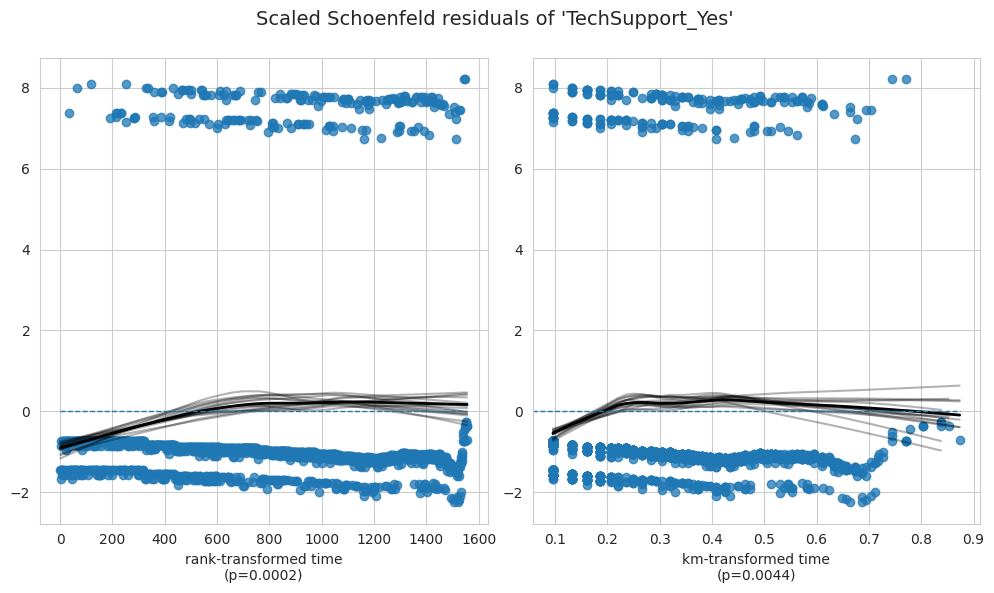

In [13]:
# 5.1 特征工程：One-hot 编码处理分类变量
encode_cols = ['Dependents', 'InternetService', 'OnlineBackup', 'TechSupport', 'PaperlessBilling']
encoded_pd = pd.get_dummies(telco_pd, columns=encode_cols, drop_first=False)

# 5.2 选择模型输入特征并确保 churn 列为浮点型
survival_pd = encoded_pd[['churn', 'tenure', 'Dependents_Yes', 'InternetService_DSL',
                          'OnlineBackup_Yes', 'TechSupport_Yes']]
survival_pd['churn'] = survival_pd['churn'].astype(float)

# 5.3 训练 CoxPH 模型
cph = CoxPHFitter(alpha=0.05)
cph.fit(survival_pd, duration_col='tenure', event_col='churn')

# 5.4 输出模型摘要与风险比 (Hazard Ratios) 可视化
cph.print_summary()
cph.plot(hazard_ratios=True)
plt.title("Cox PH Model - Hazard Ratios (95% CI)")
plt.show()

# 5.5 比例风险假设检验 (PH Assumption)
print("正在执行比例风险假设检验...")
cph.check_assumptions(survival_pd, p_value_threshold=0.05, show_plots=True)

6. AFT (加速失效时间) 模型

当 Cox 假设不成立或更关注“时间缩短/延长”效应时，使用 AFT 模型（此处采用对数逻辑分布）。

Median Survival Time (Predicted): 135.51


<lifelines.LogLogisticAFTFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 3351
number of events observed = 1556
           log-likelihood = -6838.36
         time fit was run = 2026-04-25 08:40:23 UTC

---
                                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                                
alpha_ DeviceProtection_Yes                     0.48      1.62      0.07            0.35            0.62                1.41                1.86
       InternetService_DSL                      0.38      1.47      0.08            0.23            0.53                1.26                1.71
       MultipleLines_Yes                        0.66      1.94      0.07            0.53            0.80                1.70                2.22
       OnlineBackup_Yes                         0.81      2.25      0.07            0.68            0.95                1.97                2.59
       OnlineSecurity_Yes                       0.86      2.37      0.09            0.69            1.03                2.00                2.80
       Partner_Yes                              0.68      1.97      0.07            0.55            0.81                1.73                2.24
       PaymentMethod_Bank transfer (automatic)  0.74      2.10      0.09            0.56            0.92                1.75                2.51
       PaymentMethod_Credit card (automatic)    0.80      2.22      0.10            0.61            0.99                1.84                2.68
       TechSupport_Yes                          0.69      1.99      0.09            0.52            0.86                1.68                2.36
       Intercept                                1.59      4.91      0.07            1.46            1.72                4.32                5.58
beta_  Intercept                                0.12      1.13      0.02            0.08            0.16                1.08                1.17

                                                cmp to     z      p  -log2(p)
param  covariate                                                             
alpha_ DeviceProtection_Yes                       0.00  6.88 <0.005     37.25
       InternetService_DSL                        0.00  4.98 <0.005     20.59
       MultipleLines_Yes                          0.00  9.64 <0.005     70.70
       OnlineBackup_Yes                           0.00 11.63 <0.005    101.50
       OnlineSecurity_Yes                         0.00 10.12 <0.005     77.60
       Partner_Yes                                0.00 10.21 <0.005     78.93
       PaymentMethod_Bank transfer (automatic)    0.00  8.05 <0.005     50.07
       PaymentMethod_Credit card (automatic)      0.00  8.36 <0.005     53.81
       TechSupport_Yes                            0.00  7.90 <0.005     48.37
       Intercept                                  0.00 24.47 <0.005    436.88
beta_  Intercept                                  0.00  5.71 <0.005     26.42
---
Concordance = 0.73
AIC = 13698.72
log-likelihood ratio test = 877.49 on 9 df
-log2(p) of ll-ratio test = 605.78

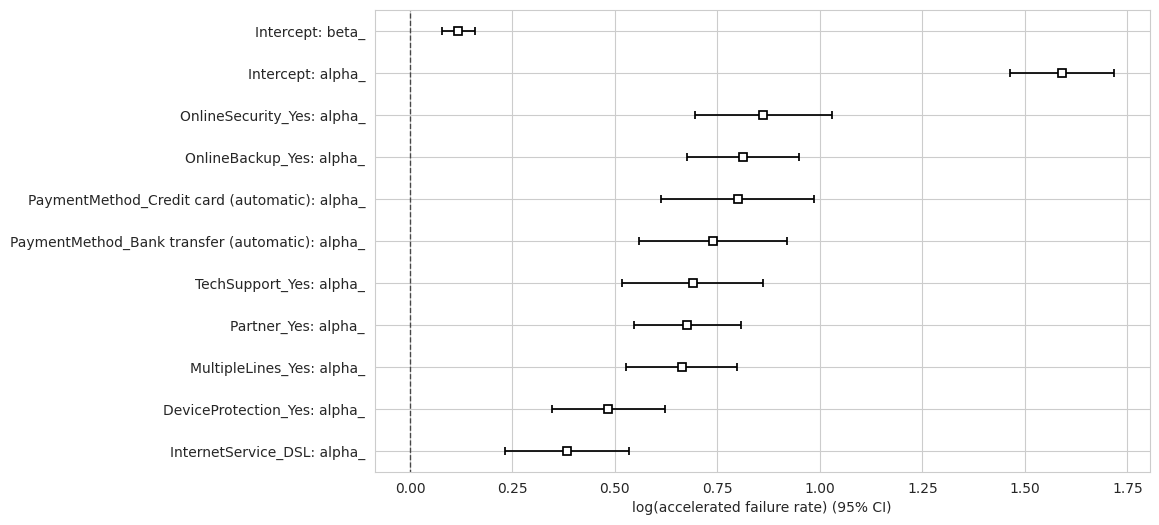

In [14]:
# 6.1 AFT 特征工程：包含更多维度的支付与服务信息
encode_cols2 = ['Partner', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaymentMethod']
encoded_pd2 = pd.get_dummies(telco_pd, columns=encode_cols2, drop_first=False)

survival_pd2 = encoded_pd2[['churn', 'tenure', 'Partner_Yes', 'MultipleLines_Yes',
                            'InternetService_DSL', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
                            'DeviceProtection_Yes', 'TechSupport_Yes',
                            'PaymentMethod_Bank transfer (automatic)',
                            'PaymentMethod_Credit card (automatic)']]

# 6.2 训练 Log-Logistic AFT 模型
aft = LogLogisticAFTFitter()
aft.fit(survival_pd2, duration_col='tenure', event_col='churn')

# 6.3 打印模型摘要与生存时间预测
print("Median Survival Time (Predicted): {:.2f}".format(np.exp(aft.median_survival_time_)))
aft.print_summary()
aft.plot()
plt.show()

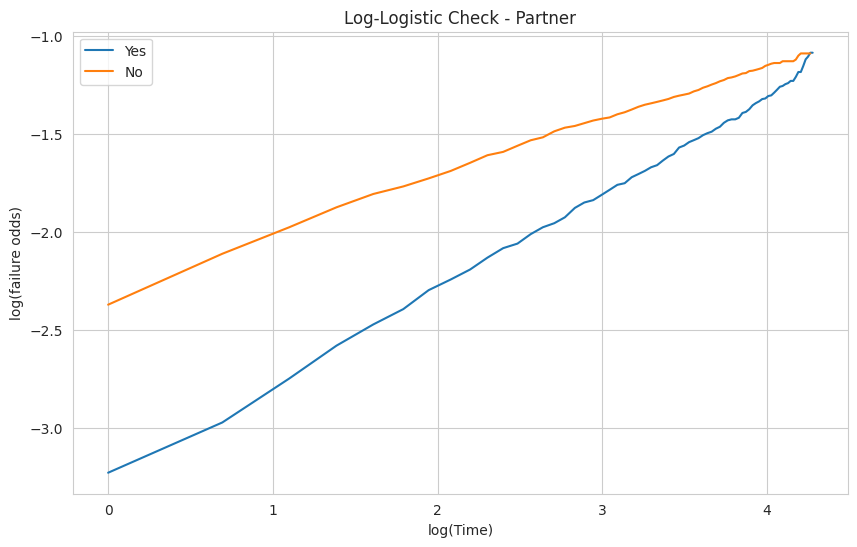

In [15]:
# AFT假设检验（log-log图）
def plot_km_logOdds(col):
    ax = plt.subplot(111)
    for r in telco_pd[col].unique():
        ix = telco_pd[col] == r
        kmf.fit(T[ix], C[ix], label=r)
        sf = kmf.survival_function_
        sf['failureOdds'] = np.log(1 - sf) / sf
        sf['logTime'] = np.log(sf.index)
        plt.plot(sf['logTime'], sf['failureOdds'], label=r)
    plt.title(f'Log-Logistic Check - {col}')
    plt.xlabel('log(Time)')
    plt.ylabel('log(failure odds)')
    plt.legend()
    plt.show()

plot_km_logOdds('Partner')

7. 客户终身价值 (CLV) 交互式仪表盘

结合生存预测曲线与折现率，计算不同客户画像的净现值 (NPV)。

Dropdown(description='Dependents:', options=(0, 1), value=0)

Dropdown(description='DSL_User:', options=(0, 1), value=0)

Dropdown(description='Backup_User:', options=(0, 1), value=0)

Dropdown(description='TechSupport:', options=(0, 1), value=0)

FloatText(value=0.1, description='Annual IRR:')

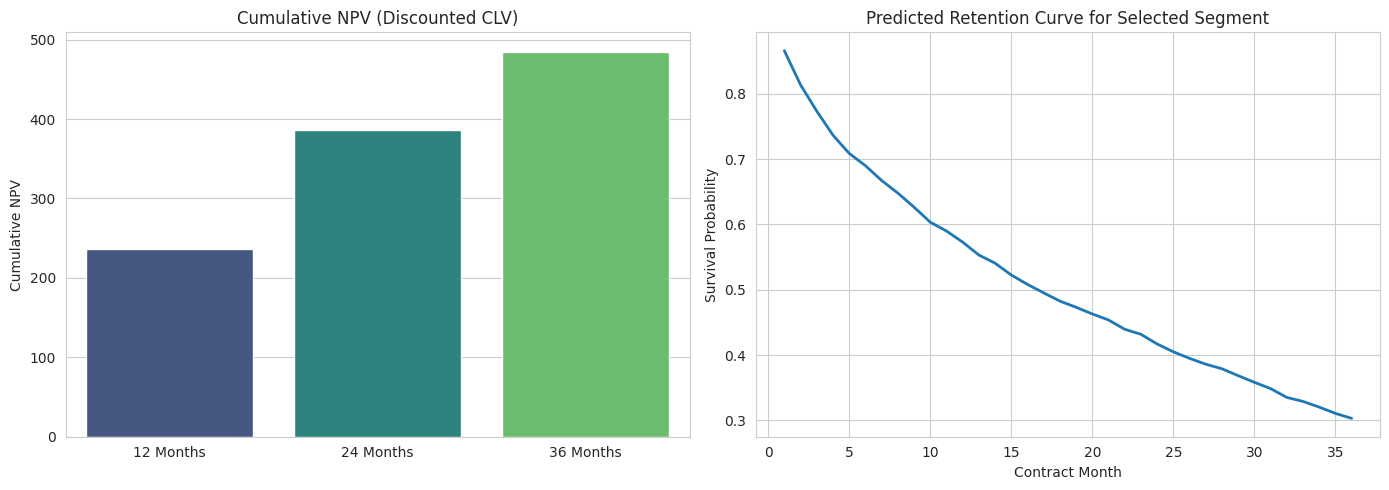

,Contract Month,Survival Probability,Avg Expected Monthly Profit,NPV,Cumulative NPV
0,1,0.865866,25.975983,25.761306,25.761306
1,2,0.813649,24.409476,24.007681,49.768987
2,3,0.773411,23.202339,22.631816,72.400802
3,4,0.736666,22.099971,21.378400,93.779203
4,5,0.708739,21.262185,20.397985,114.177188
5,6,0.690009,20.700285,19.694800,133.871987
6,7,0.667327,20.019802,18.889954,152.761942
7,8,0.648066,19.441970,18.193123,170.955065
8,9,0.626485,18.794551,17.441942,188.397007
9,10,0.603472,18.104167,16.662390,205.059398


In [16]:
import ipywidgets as widgets
from IPython.display import display

# 7.1 定义交互式 UI 控件
dependents = widgets.Dropdown(options=[0, 1], value=0, description='Dependents:')
internet = widgets.Dropdown(options=[0, 1], value=0, description='DSL_User:')
backup = widgets.Dropdown(options=[0, 1], value=0, description='Backup_User:')
support = widgets.Dropdown(options=[0, 1], value=0, description='TechSupport:')
irr = widgets.FloatText(value=0.10, description='Annual IRR:')

display(dependents, internet, backup, support, irr)

def calculate_clv_dashboard():
    # 构造单个预测样本
    df_input = pd.DataFrame({
        'Dependents_Yes': [dependents.value],
        'InternetService_DSL': [internet.value],
        'OnlineBackup_Yes': [backup.value],
        'TechSupport_Yes': [support.value]
    })
    
    # 获取预测生存曲线 (36个月)
    surv = cph.predict_survival_function(df_input).iloc[:, 0]
    irr_month = irr.value / 12
    months = range(1, 37)
    
    # 核心计算逻辑：生存概率 * 月利润 / 折现系数
    df_pay = pd.DataFrame({'Contract Month': months})
    df_pay['Survival Probability'] = surv.reindex(months, method='nearest').values
    df_pay['Avg Expected Monthly Profit'] = df_pay['Survival Probability'] * 30  # 假设月均利润 30
    df_pay['NPV'] = df_pay.apply(lambda row: row['Avg Expected Monthly Profit'] / ((1 + irr_month) ** row['Contract Month']), axis=1)
    df_pay['Cumulative NPV'] = df_pay['NPV'].cumsum()
    
    # 可视化结果
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 柱状图：不同时间节点的累计 NPV
    periods = [11, 23, 35] # 12, 24, 36月对应的索引
    sns.barplot(x=['12 Months', '24 Months', '36 Months'], 
                y=df_pay.iloc[periods]['Cumulative NPV'], ax=ax[0], palette="viridis")
    ax[0].set_title('Cumulative NPV (Discounted CLV)')
    
    # 折线图：生存预测曲线
    sns.lineplot(x=df_pay['Contract Month'], y=df_pay['Survival Probability'], ax=ax[1], lw=2)
    ax[1].set_title('Predicted Retention Curve for Selected Segment')
    
    plt.tight_layout()
    plt.show()
    return df_pay.head(12)

# 运行计算（在交互环境中，可将此封装在观察者模式下实时更新）
df_result = calculate_clv_dashboard()
display(df_result)